# Stellar Class — Features v2
**Kaggle Playground Series S6E6**

Что меняем по сравнению с baseline:
- Новые комбинации с `g` и `z` — они были топ по importance
- Квадрат и interaction для `g_z` — была фича №1
- Убираем `spectral_type` и `galaxy_population` — importance почти 0
- Убираем `alpha` и `delta` — координаты, не информативны

## 1. Импорты

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_FOLDS = 8
BASELINE_CV = 0.93721  # наш ориентир из v1

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Загрузка данных

In [2]:
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')

Train: (577347, 12)
Test:  (247435, 11)


## 3. Feature Engineering v2

Добавляем новые фичи на основе feature importance из v1:
- `g_z` была фича №1 → делаем её квадрат и interaction с redshift
- Все оставшиеся комбинации диапазонов которых не было в v1
- Убираем бесполезные категориальные фичи

In [3]:
def engineer_features_v2(df):
    df = df.copy()
    
    # ── Все цветовые индексы из v1 ──────────────────────────────
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['u_z'] = df['u'] - df['z']
    df['g_z'] = df['g'] - df['z']   # фича №1 в v1!
    df['g_i'] = df['g'] - df['i']
    
    # ── Новые комбинации v2 ──────────────────────────────────────
    df['r_z']   = df['r'] - df['z']   # r и z сильные — пробуем их разность
    df['u_i']   = df['u'] - df['i']   # u через один до i
    df['r_g']   = df['r'] - df['g']   # обратная g_r (нелинейность)
    df['i_g']   = df['i'] - df['g']   # обратная g_i
    df['z_r']   = df['z'] - df['r']   # обратная r_z
    
    # ── Трансформации redshift ───────────────────────────────────
    df['log1p_redshift'] = np.log1p(df['redshift'].clip(lower=0))
    df['redshift_sq']    = df['redshift'] ** 2
    
    # ── Новые фичи для g_z — была топ-1 ─────────────────────────
    df['g_z_sq']          = df['g_z'] ** 2
    df['g_z_x_redshift']  = df['g_z'] * df['log1p_redshift']
    df['g_z_x_u_g']       = df['g_z'] * df['u_g']
    
    # ── Interaction terms из v1 ──────────────────────────────────
    df['u_g_x_redshift'] = df['u_g'] * df['log1p_redshift']
    df['g_r_x_redshift'] = df['g_r'] * df['log1p_redshift']
    
    # ── Новые interaction terms ──────────────────────────────────
    df['r_z_x_redshift'] = df['r_z'] * df['log1p_redshift']
    df['r_i_x_redshift'] = df['r_i'] * df['log1p_redshift']
    
    return df

train = engineer_features_v2(train)
test  = engineer_features_v2(test)

print(f'Фичей после engineering v2: {train.shape[1]}')

Фичей после engineering v2: 34


## 4. Подготовка данных

Убираем:
- `alpha`, `delta` — координаты, importance = 0
- `spectral_type`, `galaxy_population` — importance почти 0 в v1

In [4]:
DROP_COLS = ['id', 'class', 'alpha', 'delta', 'spectral_type', 'galaxy_population']

FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]
TARGET_COL   = 'class'

X      = train[FEATURE_COLS]
y      = train[TARGET_COL]
X_test = test[FEATURE_COLS]

print(f'Фичей в v1: 19')
print(f'Фичей в v2: {len(FEATURE_COLS)}')
print(f'Новых фичей: {len(FEATURE_COLS) - 19}')
print(f'\nСписок: {FEATURE_COLS}')

Фичей в v1: 19
Фичей в v2: 28
Новых фичей: 9

Список: ['u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_z', 'g_i', 'r_z', 'u_i', 'r_g', 'i_g', 'z_r', 'log1p_redshift', 'redshift_sq', 'g_z_sq', 'g_z_x_redshift', 'g_z_x_u_g', 'u_g_x_redshift', 'g_r_x_redshift', 'r_z_x_redshift', 'r_i_x_redshift']


## 5. Кодирование таргета

In [6]:
le_target  = LabelEncoder()
y_encoded  = le_target.fit_transform(y)
print('Классы:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

Классы: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


## 6. Обучение модели

In [7]:
lgb_params = {
    'objective':         'multiclass',
    'num_class':         3,
    'metric':            'multi_logloss',
    'n_estimators':      1200,
    'learning_rate':     0.03,
    'num_leaves':        120,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'random_state':      RANDOM_STATE,
    'verbose':           -1,
}

skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_preds   = np.zeros((len(train), 3))
test_preds  = np.zeros((len(test), 3))
cv_scores   = []

print(f'Обучаем {N_FOLDS}-fold CV...\n')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    val_proba  = model.predict_proba(X_val)
    val_preds  = np.argmax(val_proba, axis=1)
    score      = balanced_accuracy_score(y_val, val_preds)
    cv_scores.append(score)

    oof_preds[val_idx]  = val_proba
    test_preds         += model.predict_proba(X_test) / N_FOLDS

    print(f'Fold {fold+1} | Balanced Accuracy: {score:.5f} | Деревьев: {model.best_iteration_}')

cv_mean = np.mean(cv_scores)
cv_std  = np.std(cv_scores)
delta   = cv_mean - BASELINE_CV

print(f'\n=== CV Score v2: {cv_mean:.5f} ± {cv_std:.5f} ===')
print(f'=== Baseline v1: {BASELINE_CV:.5f} ===')
print(f'=== Дельта:     {delta:+.5f} === {"✅ Улучшение!" if delta > 0 else "❌ Хуже"}')

Обучаем 8-fold CV...

[200]	valid_0's multi_logloss: 0.119959
Fold 1 | Balanced Accuracy: 0.93785 | Деревьев: 301
[200]	valid_0's multi_logloss: 0.120448
Fold 2 | Balanced Accuracy: 0.93749 | Деревьев: 279
[200]	valid_0's multi_logloss: 0.12131
Fold 3 | Balanced Accuracy: 0.93882 | Деревьев: 271
[200]	valid_0's multi_logloss: 0.124891
Fold 4 | Balanced Accuracy: 0.93569 | Деревьев: 240
[200]	valid_0's multi_logloss: 0.122281
Fold 5 | Balanced Accuracy: 0.93734 | Деревьев: 269
[200]	valid_0's multi_logloss: 0.120193
Fold 6 | Balanced Accuracy: 0.93827 | Деревьев: 278
[200]	valid_0's multi_logloss: 0.121134
Fold 7 | Balanced Accuracy: 0.93706 | Деревьев: 298
[200]	valid_0's multi_logloss: 0.122837
Fold 8 | Balanced Accuracy: 0.93787 | Деревьев: 286

=== CV Score v2: 0.93755 ± 0.00087 ===
=== Baseline v1: 0.93721 ===
=== Дельта:     +0.00034 === ✅ Улучшение!


## 7. OOF Score

In [8]:
oof_classes = np.argmax(oof_preds, axis=1)
oof_score   = balanced_accuracy_score(y_encoded, oof_classes)
print(f'OOF Balanced Accuracy: {oof_score:.5f}')

OOF Balanced Accuracy: 0.93755


## 8. Feature Importance v2

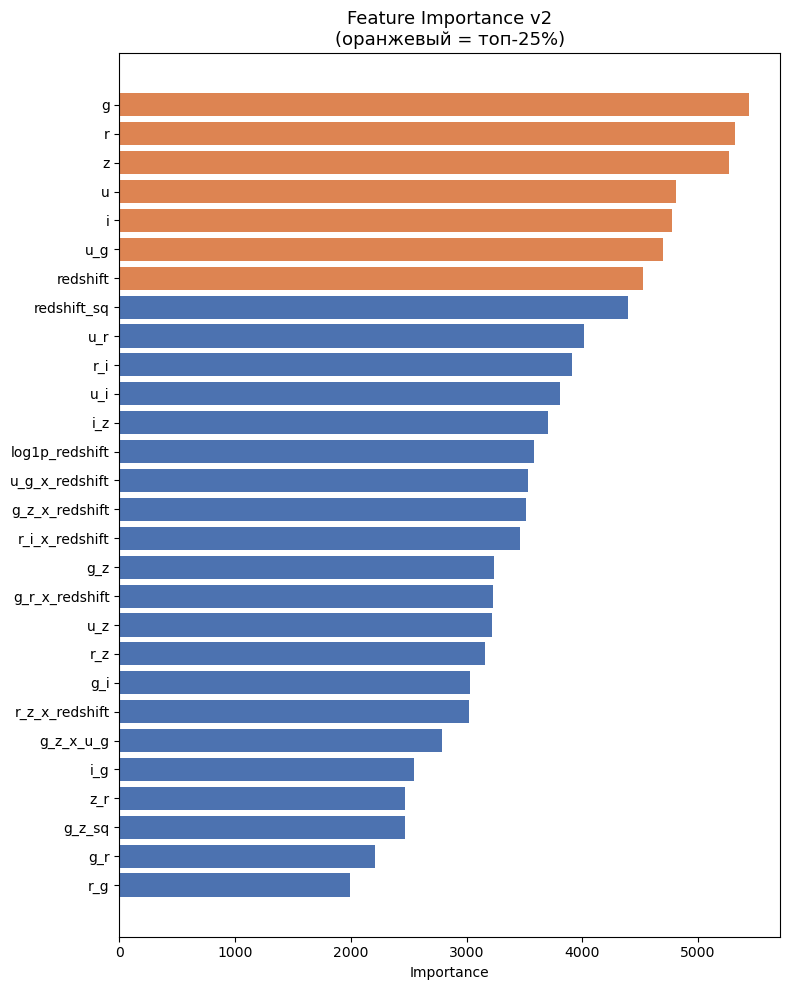

Топ-5 фичей:
feature  importance
      g        5436
      r        5323
      z        5271
      u        4807
      i        4771

Аутсайдеры (кандидаты на удаление):
feature  importance
    r_g        1996
    g_r        2204
 g_z_sq        2466
    z_r        2471
    i_g        2542


In [9]:
importance = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#DD8452' if imp > importance['importance'].quantile(0.75) else '#4C72B0'
          for imp in importance['importance']]
ax.barh(importance['feature'], importance['importance'], color=colors)
ax.set_title('Feature Importance v2\n(оранжевый = топ-25%)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Топ-5 фичей:')
print(importance.tail(5)[['feature','importance']].iloc[::-1].to_string(index=False))
print('\nАутсайдеры (кандидаты на удаление):')
print(importance.head(5)[['feature','importance']].to_string(index=False))

## 9. Сабмит

In [10]:
test_classes = np.argmax(test_preds, axis=1)
test_labels  = le_target.inverse_transform(test_classes)

submission = pd.DataFrame({
    'id':    test['id'],
    'class': test_labels
})

submission.to_csv('../submissions/submission_v2_features.csv', index=False)

print('Сабмит сохранён ✅')
print(f'Файл: submissions/submission_v2_features.csv')
print('\nРаспределение предсказаний:')
print(submission['class'].value_counts())

Сабмит сохранён ✅
Файл: submissions/submission_v2_features.csv

Распределение предсказаний:
class
GALAXY    162127
QSO        50254
STAR       35054
Name: count, dtype: int64


## 10. Сравнение v1 vs v2

In [11]:
print('=' * 45)
print(f'  Версия  │  CV Score  │  Фичей  │  Изменение')
print('─' * 45)
print(f'  v1 baseline │ {BASELINE_CV:.5f}  │   19    │  —')
print(f'  v2 features │ {cv_mean:.5f}  │   {len(FEATURE_COLS)}    │  {delta:+.5f}')
print('=' * 45)

if delta > 0.001:
    print('\n✅ Хорошее улучшение — заливаем на Kaggle!')
elif delta > 0:
    print('\n✅ Небольшое улучшение — всё равно заливаем')
else:
    print('\n❌ Не улучшилось — анализируем feature importance и пробуем другие фичи')

  Версия  │  CV Score  │  Фичей  │  Изменение
─────────────────────────────────────────────
  v1 baseline │ 0.93721  │   19    │  —
  v2 features │ 0.93755  │   28    │  +0.00034

✅ Небольшое улучшение — всё равно заливаем
